In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import requests
from bs4 import BeautifulSoup as bs
import lxml
import os

utl = "https://finance.naver.com/marketindex/exchangeList.naver"
headers = {"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36"}
res = requests.get(utl, headers = headers)
res.raise_for_status 
print(res.text)
df = pd.DataFrame()

<html lang='ko'>
<head>
<title>네이버페이 증권</title>
<meta http-equiv='Content-Type' content='text/html; charset=euc-kr'>
<meta http-equiv="Content-Script-Type" content="text/javascript">
<meta http-equiv="Content-Style-Type" content="text/css">
<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20250606114148/css/finance.css">

<script type="text/javascript" src="https://ssl.pstatic.net/imgstock/static.pc/20250606114148/js/info/jindo.min.ns.1.5.3.euckr.js"></script>
<script type="text/javascript" src="https://ssl.pstatic.net/imgstock/static.pc/20250606114148/js/ntm.js"></script>
<script type="text/javascript" src="https://ssl.pstatic.net/imgstock/static.pc/20250606114148/js/nLog.js"></script>
</head>
<body>
<div class="tbl_area">
	<table border="1" class="tbl_exchange" summary="환전 고시 환율 리스트">
	<caption>환전 고시 환율</caption>
	<colgroup>
		<col width="162">
		<col width="92">
		<col width="92">
		<col width="92">
		<col width="93">
		<col width="92">
		<col 

In [49]:
data = pd.read_html(res.text, header = 0, skiprows = 1)[0]
df= pd.concat([df,data], ignore_index = True)

df
df = df.dropna()
df = df.head(10)
df.rename(columns = {'통화명' :"국가명", "매매기준율" : "환율"}, inplace=True)
df = df[['국가명','환율']]
df

C:\Users\user\AppData\Local\Temp\ipykernel_18240\2973293685.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_html(res.text, header = 0, skiprows = 1)[0]


,국가명,환율
0,미국 USD,1361.50
1,유럽연합 EUR,1551.50
2,일본 JPY (100엔),940.17
3,중국 CNY,189.38
4,홍콩 HKD,173.50
6,영국 GBP,1842.11
8,캐나다 CAD,994.05
9,스위스 CHF,1655.92
10,스웨덴 SEK,141.16
11,호주 AUD,884.43


In [51]:
df = pd.read_csv("./data/KOBIS_역대_박스오피스.csv")
df.head()

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적,배급사
0,1,명량,2014-07-30,1.357484e+11,17613682,1587,한국,한국,(주)씨제이이엔엠
1,2,극한직업,2019-01-23,1.396480e+11,16264944,1978,한국,한국,(주)씨제이이엔엠
2,3,신과함께-죄와 벌,2017-12-20,1.156987e+11,14410754,1912,한국,한국,롯데쇼핑㈜롯데엔터테인먼트
3,4,국제시장,2014-12-17,1.109135e+11,14257115,966,한국,한국,(주)씨제이이엔엠
4,5,베테랑,2015-08-05,1.051682e+11,13414009,1064,한국,한국,(주)씨제이이엔엠


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   순위      500 non-null    int64  
 1   영화명     500 non-null    object 
 2   개봉일     500 non-null    object 
 3   매출액     490 non-null    float64
 4   관객수     500 non-null    int64  
 5   스크린수    500 non-null    int64  
 6   대표국적    500 non-null    object 
 7   국적      500 non-null    object 
 8   배급사     496 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 35.3+ KB


In [55]:
df2 = df.copy()
df2.isnull().sum()

순위       0
영화명      0
개봉일      0
매출액     10
관객수      0
스크린수     0
대표국적     0
국적       0
배급사      4
dtype: int64

In [59]:
null_rate = df2['매출액'].isnull().sum() / df2['배급사'].size*100
null_rate

2.0

In [61]:
df2.drop(['대표국적'],axis=1, inplace=True)

In [63]:
df2

,순위,영화명,개봉일,매출액,관객수,스크린수,국적,배급사
0,1,명량,2014-07-30,1.357484e+11,17613682,1587,한국,(주)씨제이이엔엠
1,2,극한직업,2019-01-23,1.396480e+11,16264944,1978,한국,(주)씨제이이엔엠
2,3,신과함께-죄와 벌,2017-12-20,1.156987e+11,14410754,1912,한국,롯데쇼핑㈜롯데엔터테인먼트
3,4,국제시장,2014-12-17,1.109135e+11,14257115,966,한국,(주)씨제이이엔엠
4,5,베테랑,2015-08-05,1.051682e+11,13414009,1064,한국,(주)씨제이이엔엠
...,...,...,...,...,...,...,...,...
495,496,비공식작전,2023-08-02,1.019214e+10,1058645,1151,한국,(주)쇼박스
496,497,남극일기,2005-05-19,0.000000e+00,1057311,78,한국,(주)쇼박스
497,498,동창생,2013-11-06,7.010197e+09,1048280,660,한국,(주)쇼박스
498,499,시크릿,2009-12-03,7.979592e+09,1046787,397,한국,씨제이엔터테인먼트


In [67]:
df2.dropna(subset='배급사', inplace=True)
df2.isnull().sum()

순위       0
영화명      0
개봉일      0
매출액     10
관객수      0
스크린수     0
국적       0
배급사      0
dtype: int64

In [69]:
df2['매출액'].fillna(0, inplace=True)
df2.isnull().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_18240\1019775179.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['매출액'].fillna(0, inplace=True)


순위      0
영화명     0
개봉일     0
매출액     0
관객수     0
스크린수    0
국적      0
배급사     0
dtype: int64

In [71]:
group_data = df.groupby('배급사').sum()

In [73]:
group_data

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적
배급사,,,,,,,,
(유)씨에이치엔터테인먼트,357,원스어폰어타임,2008-01-31,1.018014e+10,1562486,315,한국,한국
"(주)나이너스엔터테인먼트,(주)팝엔터테인먼트,씨제이엔터테인먼트",353,집으로...,2002-04-04,0.000000e+00,1576943,32,한국,한국
(주)넥스트엔터테인먼트월드(NEW),12793,7번방의 선물부산행변호인연평해전숨바꼭질감시자들안시성더 킹밀수독전바람과 함께 사라지다...,2013-01-232016-07-202013-12-182015-06-242013-0...,1.361361e+12,172061923,51181,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
"(주)넥스트엔터테인먼트월드(NEW),(주)에스비에스콘텐츠허브",289,해결사,2010-09-09,1.406391e+10,1873327,524,한국,한국
(주)마인드마크,644,30일달짝지근해: 7510,2023-10-032023-08-15,3.470240e+10,3553667,2110,한국한국,한국한국
...,...,...,...,...,...,...,...,...
"이언픽쳐스,(주)시네마서비스",318,엽기적인 그녀,2001-07-26,0.000000e+00,1735692,0,한국,한국
"주식회사 블루필름웍스,주식회사 킨스튜디오,(주)쇼박스",364,해바라기,2006-11-23,0.000000e+00,1543429,64,한국,한국
"주식회사 에이비오엔터테인먼트,메가박스중앙(주) 플러스엠 엔터테인먼트",53,범죄도시2범죄도시4범죄도시3,2022-05-182024-04-242023-05-31,3.460218e+11,34877609,8060,한국한국한국,한국한국한국


In [77]:
group_data.sort_values(by = "관객수", ascending =False, inplace=True)

In [79]:
group_data.head()

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적
배급사,,,,,,,,
(주)씨제이이엔엠,18682,"명량극한직업국제시장베테랑광해, 왕이 된 남자기생충엑시트설국열차수상한 그녀공조히말라야...",2014-07-302019-01-232014-12-172015-08-052012-0...,2.797282e+12,357136172,88373,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국한국한국한국한국한국한국,체코한국한국한국한국한국한국한국,독일한국한국한국한국한국..."
(주)쇼박스,19672,괴물도둑들암살택시운전사파묘검사외전관상국가대표디워웰컴 투 동막골터널내부자들럭키은밀하게...,2006-07-272012-07-252015-07-222017-08-022024-0...,1.903165e+12,335279803,61542,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국,홍콩한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한..."
씨제이엔터테인먼트,16483,"해운대화려한 휴가타짜좋은 놈, 나쁜 놈, 이상한 놈아저씨전우치투사부일체살인의 추억동...",2009-07-222007-07-252006-09-282008-07-172010-0...,5.246996e+11,185843562,15179,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
(주)넥스트엔터테인먼트월드(NEW),12793,7번방의 선물부산행변호인연평해전숨바꼭질감시자들안시성더 킹밀수독전바람과 함께 사라지다...,2013-01-232016-07-202013-12-182015-06-242013-0...,1.361361e+12,172061923,51181,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
롯데쇼핑㈜롯데엔터테인먼트,11283,신과함께-죄와 벌해적: 바다로 간 산적과속스캔들최종병기 활청년경찰덕혜옹주더 테러 라...,2017-12-202014-08-062008-12-032011-08-102017-0...,8.890049e+11,129180401,25050,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...


In [83]:
df2['스크린수_cut'] =pd.cut(df2['스크린수'] , bins = 10)
df2['스크린수_cut'].value_counts()

스크린수_cut
(-2.98, 298.0]      141
(298.0, 596.0]       94
(596.0, 894.0]       94
(894.0, 1192.0]      72
(1192.0, 1490.0]     45
(1490.0, 1788.0]     23
(1788.0, 2086.0]     14
(2086.0, 2384.0]      7
(2384.0, 2682.0]      4
(2682.0, 2980.0]      2
Name: count, dtype: int64

In [85]:
a = group_data.head(5)
a

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적
배급사,,,,,,,,
(주)씨제이이엔엠,18682,"명량극한직업국제시장베테랑광해, 왕이 된 남자기생충엑시트설국열차수상한 그녀공조히말라야...",2014-07-302019-01-232014-12-172015-08-052012-0...,2.797282e+12,357136172,88373,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국한국한국한국한국한국한국,체코한국한국한국한국한국한국한국,독일한국한국한국한국한국..."
(주)쇼박스,19672,괴물도둑들암살택시운전사파묘검사외전관상국가대표디워웰컴 투 동막골터널내부자들럭키은밀하게...,2006-07-272012-07-252015-07-222017-08-022024-0...,1.903165e+12,335279803,61542,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국,홍콩한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한..."
씨제이엔터테인먼트,16483,"해운대화려한 휴가타짜좋은 놈, 나쁜 놈, 이상한 놈아저씨전우치투사부일체살인의 추억동...",2009-07-222007-07-252006-09-282008-07-172010-0...,5.246996e+11,185843562,15179,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
(주)넥스트엔터테인먼트월드(NEW),12793,7번방의 선물부산행변호인연평해전숨바꼭질감시자들안시성더 킹밀수독전바람과 함께 사라지다...,2013-01-232016-07-202013-12-182015-06-242013-0...,1.361361e+12,172061923,51181,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
롯데쇼핑㈜롯데엔터테인먼트,11283,신과함께-죄와 벌해적: 바다로 간 산적과속스캔들최종병기 활청년경찰덕혜옹주더 테러 라...,2017-12-202014-08-062008-12-032011-08-102017-0...,8.890049e+11,129180401,25050,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...


In [91]:
a = a[['매출액','관객수','스크린수']]
a

,매출액,관객수,스크린수
배급사,,,
(주)씨제이이엔엠,2.797282e+12,357136172,88373
(주)쇼박스,1.903165e+12,335279803,61542
씨제이엔터테인먼트,5.246996e+11,185843562,15179
(주)넥스트엔터테인먼트월드(NEW),1.361361e+12,172061923,51181
롯데쇼핑㈜롯데엔터테인먼트,8.890049e+11,129180401,25050


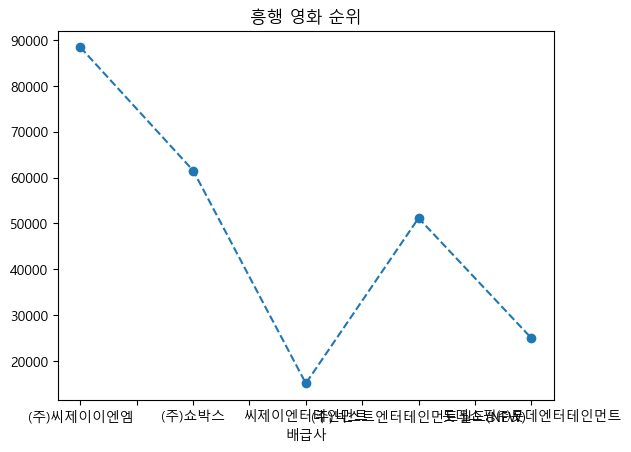

In [99]:
plt.rcParams['font.family'] = 'malgun gothic'
a.스크린수[:].plot(kind="line", rot=0, linestyle="--", marker="o")
plt.title("흥행 영화 순위")
plt.show()

In [129]:
df = pd.read_csv("./data/it_product.csv")
df1 = df.groupby(['product']).sum()
df1.sort_values(by="price", ascending = True, inplace=True)
df1.drop('year', axis=1, inplace=True)
df1

,price
product,
mouse,49000
usb,89000
iPad,1200000


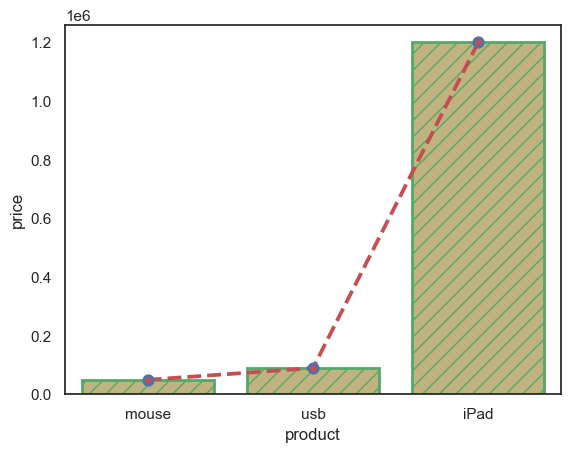

In [149]:
import seaborn as sns
sns.set_theme(style="white")
sns.barplot(x=df1.index, y = "price", data = df1, hatch="//", linewidth = 2, edgecolor = "g", color = "y")
sns.pointplot(x=df1.index, y="price", data = df1, marker="o", markeredgecolor="b", linestyle="--", color ="r")
plt.show()

In [167]:
df = pd.read_csv("./data/sungjuk.csv")
df.isnull().sum()

name     3
kor      8
eng      6
math    18
dtype: int64

In [169]:
df.dropna(subset=['name'], inplace=True)
df

,name,kor,eng,math
0,윤수진,90.0,80.0,NaN
1,김은숙,90.0,NaN,NaN
2,강수길,80.0,70.0,NaN
3,문영숙,NaN,90.0,NaN
4,김경은,100.0,80.0,NaN
5,정유진,70.0,NaN,NaN
6,윤경희,90.0,85.0,NaN
7,이은비,60.0,90.0,NaN
8,장은아,NaN,NaN,NaN
9,남희진,NaN,60.0,NaN


In [171]:
df = df[df.isnull().sum(axis=1) <2]
df

,name,kor,eng,math
0,윤수진,90.0,80.0,NaN
2,강수길,80.0,70.0,NaN
4,김경은,100.0,80.0,NaN
6,윤경희,90.0,85.0,NaN
7,이은비,60.0,90.0,NaN
10,김수빈,70.0,0.0,NaN
11,박은진,85.0,85.0,NaN
12,김성경,100.0,85.0,NaN


In [173]:
df['math'].fillna(0, inplace=True)
df

C:\Users\user\AppData\Local\Temp\ipykernel_18240\241415194.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['math'].fillna(0, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_18240\241415194.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['math'].fillna(0, inplace=True)


,name,kor,eng,math
0,윤수진,90.0,80.0,0.0
2,강수길,80.0,70.0,0.0
4,김경은,100.0,80.0,0.0
6,윤경희,90.0,85.0,0.0
7,이은비,60.0,90.0,0.0
10,김수빈,70.0,0.0,0.0
11,박은진,85.0,85.0,0.0
12,김성경,100.0,85.0,0.0


In [175]:
df['kor']= df['kor'].astype(int)
df['eng']= df['eng'].astype(int)
df['math']= df['math'].astype(int)

C:\Users\user\AppData\Local\Temp\ipykernel_18240\1014883218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kor']= df['kor'].astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_18240\1014883218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['eng']= df['eng'].astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_18240\1014883218.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

In [177]:
df

,name,kor,eng,math
0,윤수진,90,80,0
2,강수길,80,70,0
4,김경은,100,80,0
6,윤경희,90,85,0
7,이은비,60,90,0
10,김수빈,70,0,0
11,박은진,85,85,0
12,김성경,100,85,0


In [179]:
df.reset_index(drop=True, inplace=True)

In [181]:
df

,name,kor,eng,math
0,윤수진,90,80,0
1,강수길,80,70,0
2,김경은,100,80,0
3,윤경희,90,85,0
4,이은비,60,90,0
5,김수빈,70,0,0
6,박은진,85,85,0
7,김성경,100,85,0


In [185]:
df.loc[8] = ['이은비', 60,90,0]
df

,name,kor,eng,math
0,윤수진,90,80,0
1,강수길,80,70,0
2,김경은,100,80,0
3,윤경희,90,85,0
4,이은비,60,90,0
5,김수빈,70,0,0
6,박은진,85,85,0
7,김성경,100,85,0
8,이은비,60,90,0


In [187]:
df[df.duplicated(keep=False)]

,name,kor,eng,math
4,이은비,60,90,0
8,이은비,60,90,0


In [191]:
df.drop_duplicates(keep="first", inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_18240\862839905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(keep="first", inplace=True)


In [193]:
df

,name,kor,eng,math
0,윤수진,90,80,0
1,강수길,80,70,0
2,김경은,100,80,0
3,윤경희,90,85,0
4,이은비,60,90,0
5,김수빈,70,0,0
6,박은진,85,85,0
7,김성경,100,85,0


In [195]:
df.drop('math', axis=1, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_18240\4194645088.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('math', axis=1, inplace=True)


In [197]:
df

,name,kor,eng
0,윤수진,90,80
1,강수길,80,70
2,김경은,100,80
3,윤경희,90,85
4,이은비,60,90
5,김수빈,70,0
6,박은진,85,85
7,김성경,100,85


In [201]:
df = df[(df['kor'] != 0) & (df['eng'] !=0)]

In [203]:
df

,name,kor,eng
0,윤수진,90,80
1,강수길,80,70
2,김경은,100,80
3,윤경희,90,85
4,이은비,60,90
6,박은진,85,85
7,김성경,100,85


In [207]:
df.loc[df['kor'] <=60 , 'kor'] = 65

In [209]:
df

,name,kor,eng
0,윤수진,90,80
1,강수길,80,70
2,김경은,100,80
3,윤경희,90,85
4,이은비,65,90
6,박은진,85,85
7,김성경,100,85


In [213]:
df['순위'] = (df['kor'] + df['eng']).rank(method="dense", ascending = False).astype(int)
df

C:\Users\user\AppData\Local\Temp\ipykernel_18240\1780746334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['순위'] = (df['kor'] + df['eng']).rank(method="dense", ascending = False).astype(int)


,name,kor,eng,순위
0,윤수진,90,80,4
1,강수길,80,70,6
2,김경은,100,80,2
3,윤경희,90,85,3
4,이은비,65,90,5
6,박은진,85,85,4
7,김성경,100,85,1


In [217]:
df.sort_values(by ="순위", ascending = True, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_18240\1923456651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by ="순위", ascending = True, inplace=True)


In [219]:
df

,name,kor,eng,순위
7,김성경,100,85,1
2,김경은,100,80,2
3,윤경희,90,85,3
0,윤수진,90,80,4
6,박은진,85,85,4
4,이은비,65,90,5
1,강수길,80,70,6


In [223]:
df = pd.read_csv("./data/temperatures.csv")
df

,날짜,기온
0,1981-01-02,17.9
1,1981-01-03,18.8
2,1981-01-04,14.6
3,1981-01-05,15.8
4,1981-01-06,15.8
...,...,...
3655,1990-12-28,13.6
3656,1990-12-29,13.5
3657,1990-12-30,15.7
3658,1990-12-31,13.0


In [237]:
df[['날짜','기온']].duplicated(keep=False).sum()

6

In [239]:
df.drop_duplicates(keep="first", inplace=True)

In [241]:
df.duplicated().sum()

0

In [243]:
df.isnull().sum()

날짜    0
기온    8
dtype: int64

In [245]:
df.dropna(subset=['기온'], inplace=True)

In [247]:
df

,날짜,기온
0,1981-01-02,17.9
1,1981-01-03,18.8
2,1981-01-04,14.6
3,1981-01-05,15.8
4,1981-01-06,15.8
...,...,...
3654,1990-12-27,14.0
3655,1990-12-28,13.6
3656,1990-12-29,13.5
3657,1990-12-30,15.7


In [249]:
df['날짜'] = pd.to_datetime(df['날짜'])
df.dtypes

날짜    datetime64[ns]
기온           float64
dtype: object

In [273]:
df1 = df.groupby(df['날짜'].dt.year)['기온'].mean()
reindexdata = df1.reset_index()

In [275]:
reindexdata

,날짜,기온
0,1981,11.492033
1,1982,10.783562
2,1983,11.187397
3,1984,10.591781
4,1985,11.137534
5,1986,10.803288
6,1987,10.853151
7,1988,11.972055
8,1989,11.261918
9,1990,11.669589


In [279]:
df = reindexdata.query('날짜 >=1985 & 날짜 <=1990')
df

,날짜,기온
4,1985,11.137534
5,1986,10.803288
6,1987,10.853151
7,1988,11.972055
8,1989,11.261918
9,1990,11.669589


C:\Users\user\AppData\Local\Temp\ipykernel_18240\3573301437.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="날짜",y="기온",data = df, palette= color, width = 0.7)


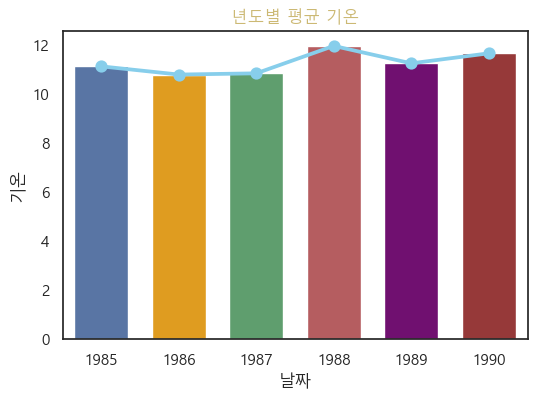

In [287]:
plt.rcParams['font.family'] = 'malgun gothic'
plt.figure(figsize=(6,4))
color = ['b','orange','g','r','purple','brown']
sns.barplot(x="날짜",y="기온",data = df, palette= color, width = 0.7)
sns.pointplot(x="날짜",y="기온",data = df, color = "skyblue")
plt.title("년도별 평균 기온", color = "y")
plt.draw()
plt.savefig("./images/bar_point_chat.jpg", dpi=300)

In [299]:
df = pd.read_csv("./data/분양가동향.csv", encoding= "cp949")

In [301]:
pd.to_numeric(df['분류'], errors = 'coerce')

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
234   NaN
235   NaN
236   NaN
237   NaN
238   NaN
Name: 분류, Length: 239, dtype: float64